# 05 — Customer Segmentation

**Pipeline:** `01_features` → `02_clv_bgnbd` → `03_clv_modeling` → `04_churn` → **`05_segmentation`** → `06_evaluation`

| | |
|---|---|
| **Depends on** | `feature_table_v2.parquet` enriched by notebook 04 (includes BG/NBD scores + all model features) |
| **Produces** | `data/models/segmentation_kmeans.json` · `data/scored/customer_segments.parquet` |

---

**Owner:** Kimberly (M2 — CLV / segmentation / experimental design)

Segments the Miracle customer base on RFM + behavioural features so the rest of the product (recommender, demo) can act per segment rather than per individual. The saved `segmentation_kmeans.json` (scaler + centroids + names) is what `score_customers.py` uses to tag every customer with a segment at inference time — assignment is pure numpy, no sklearn dependency.

> Note: ~88% of Miracle customers are one-time buyers, so expect one large low-frequency cluster. That is a real finding about the business, not a clustering artefact.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data"

# churn_training_features.parquet is the 395k-row temporal training set written
# by notebook 04 (split-date RFM + behavioural + BG/NBD scores + demographics).
# feature_table_v2.parquet is the full 751k-row snapshot and is NOT used here.
df = pd.read_parquet(DATA / "features" / "churn_training_features.parquet")
print(f"{len(df):,} customers loaded")
df.head()

395,612 customers loaded


,customer_id,is_churned,t,recency,days_since_last_order,frequency,total_orders,refund_count,refund_rate,monetary_value,...,pricebucket_premium,is_us,gender_female,gender_male,gender_unknown,region_midwest,region_northeast,region_other,region_south,region_west
0,000002094a200abd84e6cd40a850edd5,1,325,0,325,0,1,0,0.0,121.48,...,1,1,False,False,True,False,False,False,True,False
1,00000de079cccf005064ffd1f4f99836,1,165,0,165,0,1,0,0.0,119.48,...,0,1,True,False,False,True,False,False,False,False
2,000069a60a9fbb69487791f26b20a22a,1,297,0,297,0,1,0,0.0,127.54,...,0,1,True,False,False,False,False,False,False,True
3,00007f9cc42980af27e0f60e6fa17975,1,102,0,102,0,1,0,0.0,111.45,...,0,1,True,False,False,True,False,False,False,False
4,000091ac9d833a18dd2bee17b2f00288,1,490,3,486,1,2,0,0.0,79.01,...,0,1,False,False,True,False,False,False,True,False


## 1. Feature selection

We cluster on the classic RFM signals plus two behavioural ones:

- **Recency** — `days_since_last_order`
- **Frequency** — `total_orders`
- **Monetary** — `total_revenue` (log1p, right-skewed)
- **Basket size** — `avg_order_value` (log1p)
- **Dissatisfaction** — `refund_rate`

Monetary and basket size are heavily right-skewed, so we `log1p` them before
scaling. Then standardize so KMeans (a distance method) treats each feature
on the same scale.

In [2]:
FEATS = ["days_since_last_order", "total_orders", "total_revenue", "avg_order_value", "refund_rate"]
LOG   = {"total_revenue", "avg_order_value", "total_orders"}

X = df[FEATS].copy()
for c in LOG:
    X[c] = np.log1p(X[c].clip(lower=0))

scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
print("feature matrix:", Xs.shape)
print("heads-up: customers with > 50 orders (likely wholesale / heavy subscription):", int((df["total_orders"] > 50).sum()))

feature matrix: (395612, 5)
heads-up: customers with > 50 orders (likely wholesale / heavy subscription): 31


## 2. Choose *k* by silhouette

We scan k = 2..7 and pick the k with the best average silhouette (how cleanly
separated the clusters are). We also plot inertia (the elbow) for context.

silhouette by k: {2: 0.656, 3: 0.498, 4: 0.534, 5: 0.447, 6: 0.466, 7: 0.475}
rejected as degenerate: [2, 3, 4]
best k = 6


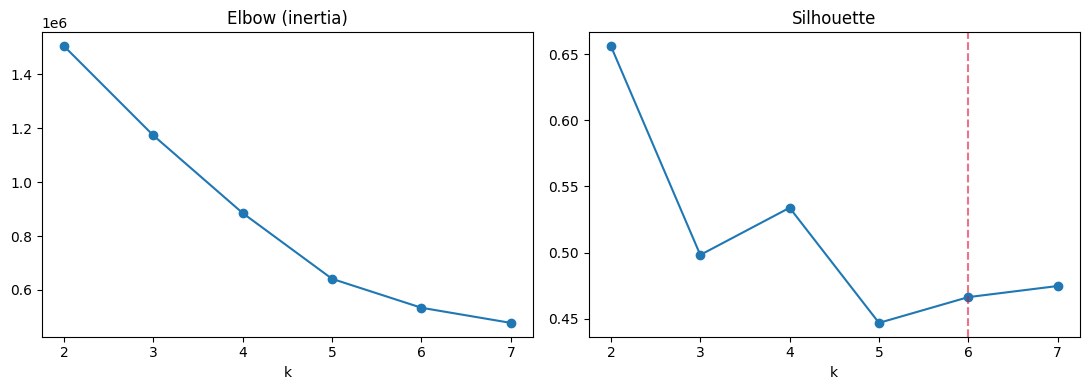

In [3]:
sil, inertia, shares = {}, {}, {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs)
    inertia[k] = km.inertia_
    sil[k] = silhouette_score(Xs, km.labels_, sample_size=min(5000, len(Xs)), random_state=42)
    sh = np.bincount(km.labels_) / len(km.labels_)
    shares[k] = (sh.max(), sh.min())   # (largest cluster share, smallest cluster share)

# Don't pick k by raw silhouette: it favors a degenerate 2-cluster split here
# (a tiny full-refund group separates trivially -> one ~96% blob + outliers).
# Rule: reject degenerate solutions, then take the simplest k whose silhouette
# is within a small margin of the best acceptable one.
MAX_DOMINANCE = 0.60   # no single cluster may hold more than 60% of the base
MIN_SHARE     = 0.01   # and no cluster may be a throwaway sliver (< 1%)
TOL           = 0.02   # silhouettes within this margin count as "as good as"

valid = [k for k in sil if shares[k][0] <= MAX_DOMINANCE and shares[k][1] >= MIN_SHARE]
if valid:
    best_sil = max(sil[k] for k in valid)
    best_k = min(k for k in valid if sil[k] >= best_sil - TOL)   # simplest k that's ~as good
else:
    best_k = max(sil, key=sil.get)                               # fallback: plain silhouette

print("silhouette by k:", {k: round(v, 3) for k, v in sil.items()})
print("rejected as degenerate:", [k for k in sil if k not in valid])
print("best k =", best_k)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(inertia), list(inertia.values()), "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(list(sil), list(sil.values()), "o-"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
ax[1].axvline(best_k, color="crimson", ls="--", alpha=.6)
plt.tight_layout(); plt.show()

## 3. Fit KMeans and profile the clusters

Profiles are shown in original units (not standardized) so they are readable.

In [4]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=42).fit(Xs)
df["segment_id"] = km.labels_

profile = (df.groupby("segment_id")
             .agg(customers=("customer_id", "size"),
                  recency_days=("days_since_last_order", "mean"),
                  orders=("total_orders", "mean"),
                  revenue=("total_revenue", "mean"),
                  aov=("avg_order_value", "mean"),
                  refund_rate=("refund_rate", "mean"))
             .round(2))
profile["share"] = (profile["customers"] / len(df) * 100).round(1).astype(str) + "%"
profile

,customers,recency_days,orders,revenue,aov,refund_rate,share
segment_id,,,,,,,
0,133164,380.32,1.01,178.76,178.30,0.00,33.7%
1,5762,403.36,1.37,0.01,0.01,0.02,1.5%
2,44385,181.35,2.85,389.95,166.69,0.02,11.2%
3,5726,224.13,1.03,168.14,163.20,1.08,1.4%
4,191597,139.47,1.00,178.16,178.16,0.00,48.4%
5,14978,243.53,1.12,29.70,27.32,0.00,3.8%


## 4. Name the segments

We name clusters from an RFM composite (recent + frequent + high-spend = best).
These names are heuristic starting points — rename to match how the brand talks
about its customers. The names get saved and flow straight into the demo.

In [5]:
# Name each segment from its actual profile. The base is ~88% one-time buyers,
# so the usual Champions->Lost ladder doesn't fit (almost every cluster has ~1
# order). Name by what each cluster really is, splitting one-timers by recency.
RECENT_CUT = 270   # days; recent vs gone-cold split for one-time buyers

def name_segment(row):
    if row["refund_rate"] >= 0.5:   return "High returns"
    if row["orders"]      >= 2.0:   return "Repeat buyers"
    if row["revenue"]     <  5.0:   return "Near-zero value"
    if row["aov"]         <  50.0:  return "Low value"
    return "Recent one-timers" if row["recency_days"] < RECENT_CUT else "Dormant one-timers"

segment_names, used = {}, set()
for cid in profile.index:
    nm = name_segment(profile.loc[cid])
    if nm in used:                 # keep distinct if two clusters match the same rule
        nm = f"{nm} ({cid})"
    segment_names[cid] = nm
    used.add(nm)

df["segment"] = df["segment_id"].map(segment_names)
for cid in profile.index:
    print(f"  cluster {cid} -> {segment_names[cid]:18s} ({profile.loc[cid,'share']} of base)")

  cluster 0 -> Dormant one-timers (33.7% of base)
  cluster 1 -> Near-zero value    (1.5% of base)
  cluster 2 -> Repeat buyers      (11.2% of base)
  cluster 3 -> High returns       (1.4% of base)
  cluster 4 -> Recent one-timers  (48.4% of base)
  cluster 5 -> Low value          (3.8% of base)


## 5. Visualize

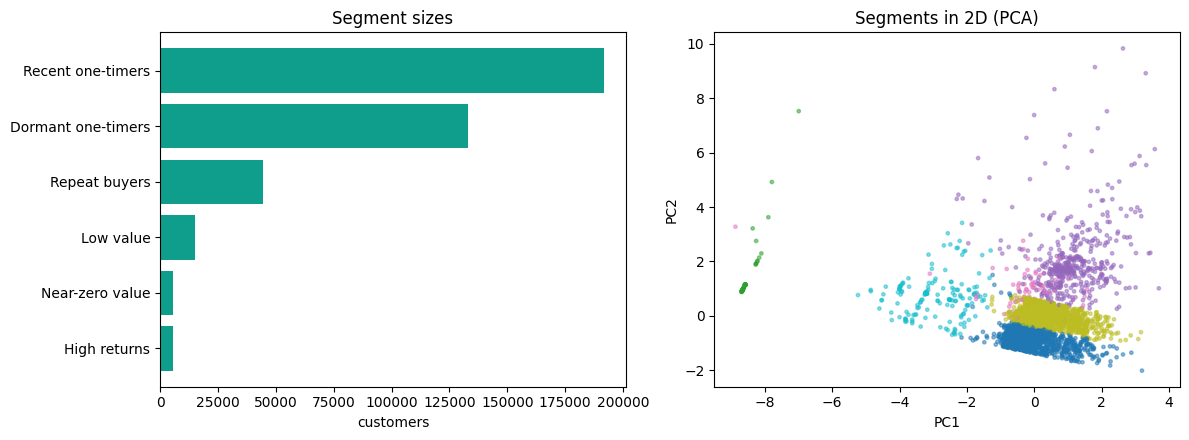

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# cluster sizes
sizes = df["segment"].value_counts()
ax[0].barh(sizes.index[::-1], sizes.values[::-1], color="#0F9D8C")
ax[0].set_title("Segment sizes"); ax[0].set_xlabel("customers")

# PCA 2D scatter (sample for speed)
samp = df.sample(min(4000, len(df)), random_state=42)
pcs = PCA(n_components=2, random_state=42).fit_transform(scaler.transform(
    samp[FEATS].assign(**{c: np.log1p(samp[c].clip(lower=0)) for c in LOG})))
sc = ax[1].scatter(pcs[:, 0], pcs[:, 1], c=samp["segment_id"], cmap="tab10", s=6, alpha=.5)
ax[1].set_title("Segments in 2D (PCA)"); ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2")
plt.tight_layout(); plt.show()

### Segment profile heatmap

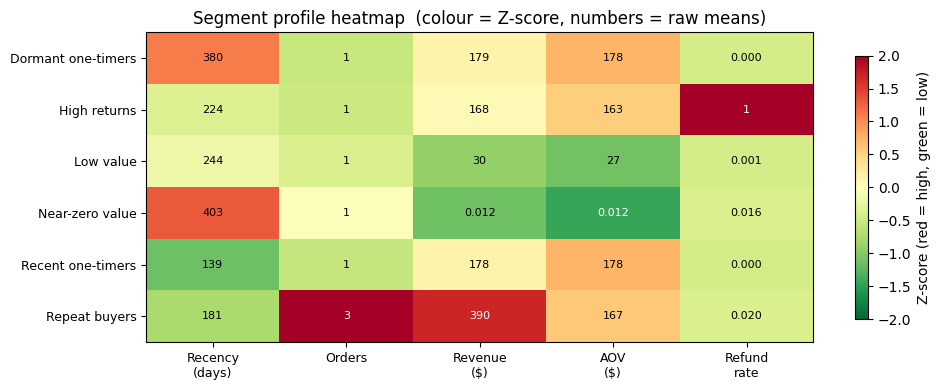

In [7]:
PROFILE_COLS = ["days_since_last_order", "total_orders", "total_revenue", "avg_order_value", "refund_rate"]
COL_LABELS   = ["Recency\n(days)", "Orders", "Revenue\n($)", "AOV\n($)", "Refund\nrate"]

seg_means = df.groupby("segment")[PROFILE_COLS].mean()
seg_z     = (seg_means - seg_means.mean()) / seg_means.std()

fig, ax = plt.subplots(figsize=(10, 4))
img = ax.imshow(seg_z.values, cmap="RdYlGn_r", aspect="auto", vmin=-2, vmax=2)
ax.set_xticks(range(len(COL_LABELS)));      ax.set_xticklabels(COL_LABELS, fontsize=9)
ax.set_yticks(range(len(seg_means.index))); ax.set_yticklabels(seg_means.index, fontsize=9)

for i in range(seg_z.shape[0]):
    for j in range(seg_z.shape[1]):
        raw = seg_means.values[i, j]
        txt = f"{raw:,.0f}" if raw >= 1 else f"{raw:.3f}"
        col = "white" if abs(seg_z.values[i, j]) > 1.4 else "black"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8, color=col)

plt.colorbar(img, ax=ax, shrink=0.85, label="Z-score (red = high, green = low)")
ax.set_title("Segment profile heatmap  (colour = Z-score, numbers = raw means)")
plt.tight_layout()
plt.savefig("../docs/figures/segmentation_profile_heatmap.png", dpi=120)
plt.show()

## 6. Save for scoring + verify numpy parity

We save the scaler, centroids and names. `score_customers.py` reproduces the
assignment with numpy only (standardize, nearest centroid). We confirm that
numpy assignment matches sklearn exactly before trusting it downstream.

In [8]:
payload = {
    "features": FEATS,
    "log_features": sorted(LOG),
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "centroids": km.cluster_centers_.tolist(),
    "k": int(best_k),
    "segment_names": {str(k): v for k, v in segment_names.items()},
    "silhouette": round(float(sil[best_k]), 4),
}
(DATA / "models").mkdir(parents=True, exist_ok=True)
json.dump(payload, open(DATA / "models" / "segmentation_kmeans.json", "w"), indent=2)

# per-customer assignment, handy for joins / the eval notebook
(DATA / "scored").mkdir(parents=True, exist_ok=True)
df[["customer_id", "segment_id", "segment"]].to_parquet(DATA / "scored" / "customer_segments.parquet", index=False)
print("saved data/models/segmentation_kmeans.json and data/scored/customer_segments.parquet")

def assign(row, p):
    feats, logset = p["features"], set(p["log_features"])
    x = np.array([np.log1p(max(row[f], 0)) if f in logset else row[f] for f in feats], float)
    xs = (x - np.array(p["scaler_mean"])) / np.array(p["scaler_scale"])
    return int(((np.array(p["centroids"]) - xs) ** 2).sum(1).argmin())

p = json.load(open(DATA / "models" / "segmentation_kmeans.json"))
sample = df.sample(min(500, len(df)), random_state=1)
match = (sample.apply(lambda r: assign(r, p), axis=1).values == sample["segment_id"].values).mean()
print(f"numpy assignment matches sklearn on {len(sample)} rows: {match*100:.0f}%")

saved data/models/segmentation_kmeans.json and data/scored/customer_segments.parquet
numpy assignment matches sklearn on 500 rows: 100%


## Takeaways

- Segments are saved and flow into the demo through `score_customers.py` (each
  at-risk customer shows its segment).
- Expect one large low-frequency / one-time segment — that is the 88% one-time
  buyer reality, and it doubles as the product's positioning angle (turning
  one-timers into repeats is the headline opportunity).
- Silhouette on this base is modest (overlapping behaviour is normal for DTC),
  so treat segments as **actionable groupings**, not hard natural classes.

**Next:** `06_evaluation.ipynb` checks model quality (churn honesty, CLV sanity,
segment separation).